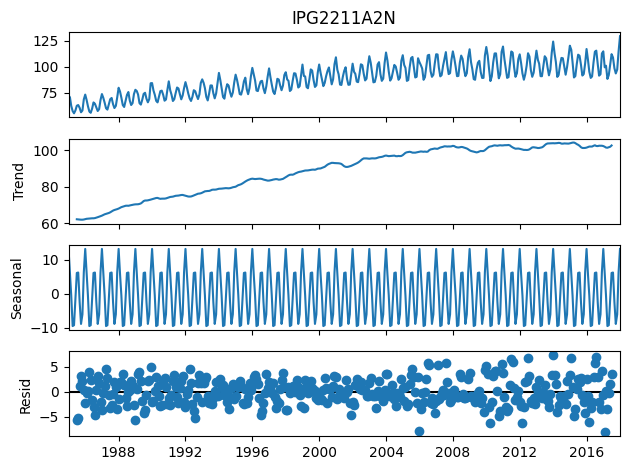

In [7]:
# extract trend, seasonality and residuals from the data given.
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"C:\Users\mayur.nikam\Downloads\Electric_Production.csv")

# Convert date column to datetime
df["DATE"] = pd.to_datetime(df["DATE"])

# Set date as index
df.set_index("DATE", inplace=True)

# Decompose time series
result = seasonal_decompose(df["IPG2211A2N"], model="additive", period=12)

# Plot components
result.plot()
plt.show()


In [10]:
#check for stationarity using ADF and kpss test.

import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# Load data
df = pd.read_csv(r"C:\Users\mayur.nikam\Downloads\Electric_Production.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

# Select the time series column
ts = df["DATE"].dropna()

# -------- ADF Test --------
adf_result = adfuller(ts)

print("ADF Test")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# -------- KPSS Test --------
kpss_result = kpss(ts, regression='c')

print("\nKPSS Test")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])


ADF Test
ADF Statistic: -0.14017905755751228
p-value: 0.9452865588328323

KPSS Test
KPSS Statistic: 3.1565941846339873
p-value: 0.01


C:\Users\mayur.nikam\AppData\Local\Temp\ipykernel_8188\1055975878.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts, regression='c')


In [11]:
#Apply linear regression for time series forecasting using feature extraction
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv(r"C:\Users\mayur.nikam\Downloads\Electric_Production.csv")

# Select time series column
df["lag1"] = df["IPG2211A2N"].shift(1)
df["lag2"] = df["IPG2211A2N"].shift(2)

# Drop missing values
df = df.dropna()

# Features and target
X = df[["lag1", "lag2"]]
y = df["IPG2211A2N"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Forecast
y_pred = model.predict(X_test)

print("Forecasted values:")
print(y_pred[:5])


Forecasted values:
[105.6293731  114.96466053 108.05171914  90.47373511  85.32324067]
